# 리포트 8-5 — 마이크로도플러: **바이스태틱**

> **도플러는 이등분선이 정하고, 플래시는 방위가 정한다. 둘은 같이 안 움직인다.**

8 권의 앞 네 편(8-1~8-4)의 맵은 전부 **모노스태틱**이다 — 송신국과 수신국이 같은 자리에 있다. 그런데 우리 실증은 **패시브 바이스태틱**이다: 조명은 남의 기지국이 하고 우리는 떨어진 곳에서 받는다. 그래서 «모노에서 본 무늬가 바이스태틱에서 그대로인가» 는 8 권 모노 편이 답하지 않은 질문으로 남아 있었다. 이 편이 그것만 한다.

**이 편에 처음 나오는 말 넷.** **바이스태틱각 β** 는 표적이 송신국과 수신국을 보는 사잇각이고, **이등분선** 은 그 각을 반으로 가르는 방향이다(β=0 이면 모노스태틱). **플래시** 는 블레이드가 그 방향에 정렬하는 순간 에코가 튀는 밝은 줄이고, **슬로타임** 은 한 번의 관측 안에서 표본과 표본 사이로 흐르는 시간축이다 — 마이크로도플러 무늬는 그 축 위에 그려진다.

| 무엇 | 값 |
|---|---|
| 표적 | DJI Matrice 4E · 호버 |
| 조명 시선 û_i | 방위 0° · 앙각 -15° (8 권 모노 편 그대로, **고정**) |
| 바이스태틱각 β | 0°, 30°, 60°, 90°, 120° · 평면 두 개 |
| 반송파 | 3.5 GHz |
| 슬로타임 | 4,096 표본 @ PRF 19700 Hz = 208 ms = 26.3 블레이드 주기 |
| 커널 | `rcs_sbr.sbr_field_bistatic` — 바이스태틱 **복소장** E(û_i, û_s) |

⭐ **한 줄 요약 세 개**

1. **도플러는 줄어든다 — 그런데 교과서의 cos(β/2) 로는 아니다.** 날개끝 도플러의 축척은 이등분선의 **수평 성분**이 정한다. 두 예측은 우리 기하에서 최대 27 % 갈리고, 실측은 상대 rms 오차 **0.061 대 0.126** 로 이등분선 쪽을 고른다.
2. **플래시는 도플러와 따로 논다.** 플래시 **주기**는 β 가 어떻든 로터가 정한다(8/9 칸이 공칭 126.7 Hz 의 ±0.8 Hz 안). 반면 플래시가 **언제** 터지는지는 이등분선의 **방위**가 정한다 — 방위를 안 돌리는 앙각면에서는 β 90° 까지도 플래시열이 제자리다(상관 0.98).
3. **에코는 약해진다.** 조명게이트 ∩ 수신게이트에 남는 투영 유효면적이 β 120° 에서 모노의 **28 %** 로 줄어든다. 측정 에코는 방위면에서 -17.5 ~ -10.4 dB 사이를 **오르내린다** — 단조 감소가 아니다(코히어런트 간섭 — 아래 절 3).

⚠ **이 편은 기하만 본다.** 기준채널/감시채널 2채널 처리(ECA·CAF)는 `src/passive_process.py` 에 있지만 여기서 **쓰지 않는다**. 경계는 절 5 에 적었다.


## 절 0. 시나리오 — 무엇을 바꿨고 무엇을 안 바꿨나

**안 바꾼 것**: 기체·자세·반송파·로터별 회전수·PRF·표본 수. 이 값들을 손으로 다시 적지 않고 `outputs/report07_three_engines.json` 의 `_meta` 에서 **읽어서** 쓴다. 그래야 8 권 모노 편의 판과 사과-대-사과가 된다.

**바꾼 것**: 수신 방향 û_s 하나. û_i 는 8 권 모노 편의 시선에 고정한 채, û_s 를 정해진 평면에서 β 만큼 연다.

| 평면 | 무엇인가 | 왜 |
|---|---|---|
| **방위면** (본 스윕) | 두 지상국이 **같은 부각 -15°** 원뿔 위에 있고 방위만 φ 벌어진다 | 조명 기지국도 우리 수신기도 지상에 있고 표적이 그 위에 떠 있다 — 패시브 바이스태틱의 실제 기하 |
| **앙각면** (대조군) | 같은 수직면 안에서 수신기가 β 만큼 올라간다 | 이등분선의 **방위가 안 변한다** — 플래시(기하)와 도플러(운동)를 갈라 보려고 |

⚠ **방위차 φ 는 β 가 아니다.** 등부각 원뿔 위의 두 점이라 항상 φ ≥ β 이고, cos β = cos²el·cos φ + sin²el 을 φ 에 대해 풀어 β 를 **정확히** 맞춘다. 이 원뿔이 낼 수 있는 최대 β 는 **150°** 다(그 너머는 앙각면만 닿는다).

| β | 방위차 φ | 이등분선 방위 | 이등분선 앙각 |
|---|---|---|---|
| 0° | 0.00° | 0.00° | -15.00° |
| 30° | 31.08° | 15.54° | -15.54° |
| 60° | 62.35° | 31.17° | -17.39° |
| 90° | 94.12° | 47.06° | -21.47° |
| 120° | 127.42° | 63.71° | -31.17° |

**⭐ 회귀 — β=0 이 8 권 모노 편의 원장과 같은가**

바이스태틱 커널은 û_s=û_i 에서 모노 커널의 특수해여야 한다. 세 자리에서 확인한다.

| 회귀 | 대상 | 최대 상대오차 | 비트동일 |
|---|---|---|---|
| ① 커널 항등 | `sbr_field` ↔ `sbr_field_bistatic(û_s=û_i)`, 같은 씬 객체 | 0.0e+00 | 64/64 |
| ② 모노 원장 | 이 스윕의 β=0 열 ↔ `outputs/report07_three_engines.npz['sbr']` | 0.0e+00 | 4096/4096 |
| ③ PO 대조팔 | 이 편의 PO 팔 β=0 ↔ `outputs/report07_three_engines.npz['po']` | 0.0e+00 | 4096/4096 |

세 줄 모두 **검사한 프레임이 전부 비트 단위로 같다** — ①은 커널 두 함수를 맞댄 64 프레임 표본이고, ②③ 은 슬로타임 4,096 프레임 전부다. 즉 이 편의 β=0 칸은 8 권 모노 편의 그 칸이지 «비슷한 것» 이 아니다. β>0 에서 달라지는 것은 전부 기하 때문이다.

⭐ β=0 은 부동소수 잔차 없이 **û_s ≡ û_i** 로 특수화한다 — φ 를 arccos 로 풀면 β=0 에서 1e-8 도쯤의 잔차가 남고, 그 잔차가 위상에 실려 회귀 게이트를 2e-8 만큼 깨뜨린다.


## 그림 1 — 바이스태틱이 되면 기하가 무엇을 바꾸는가

숫자를 보기 전에, 무엇이 달라지는지부터 못박는다.

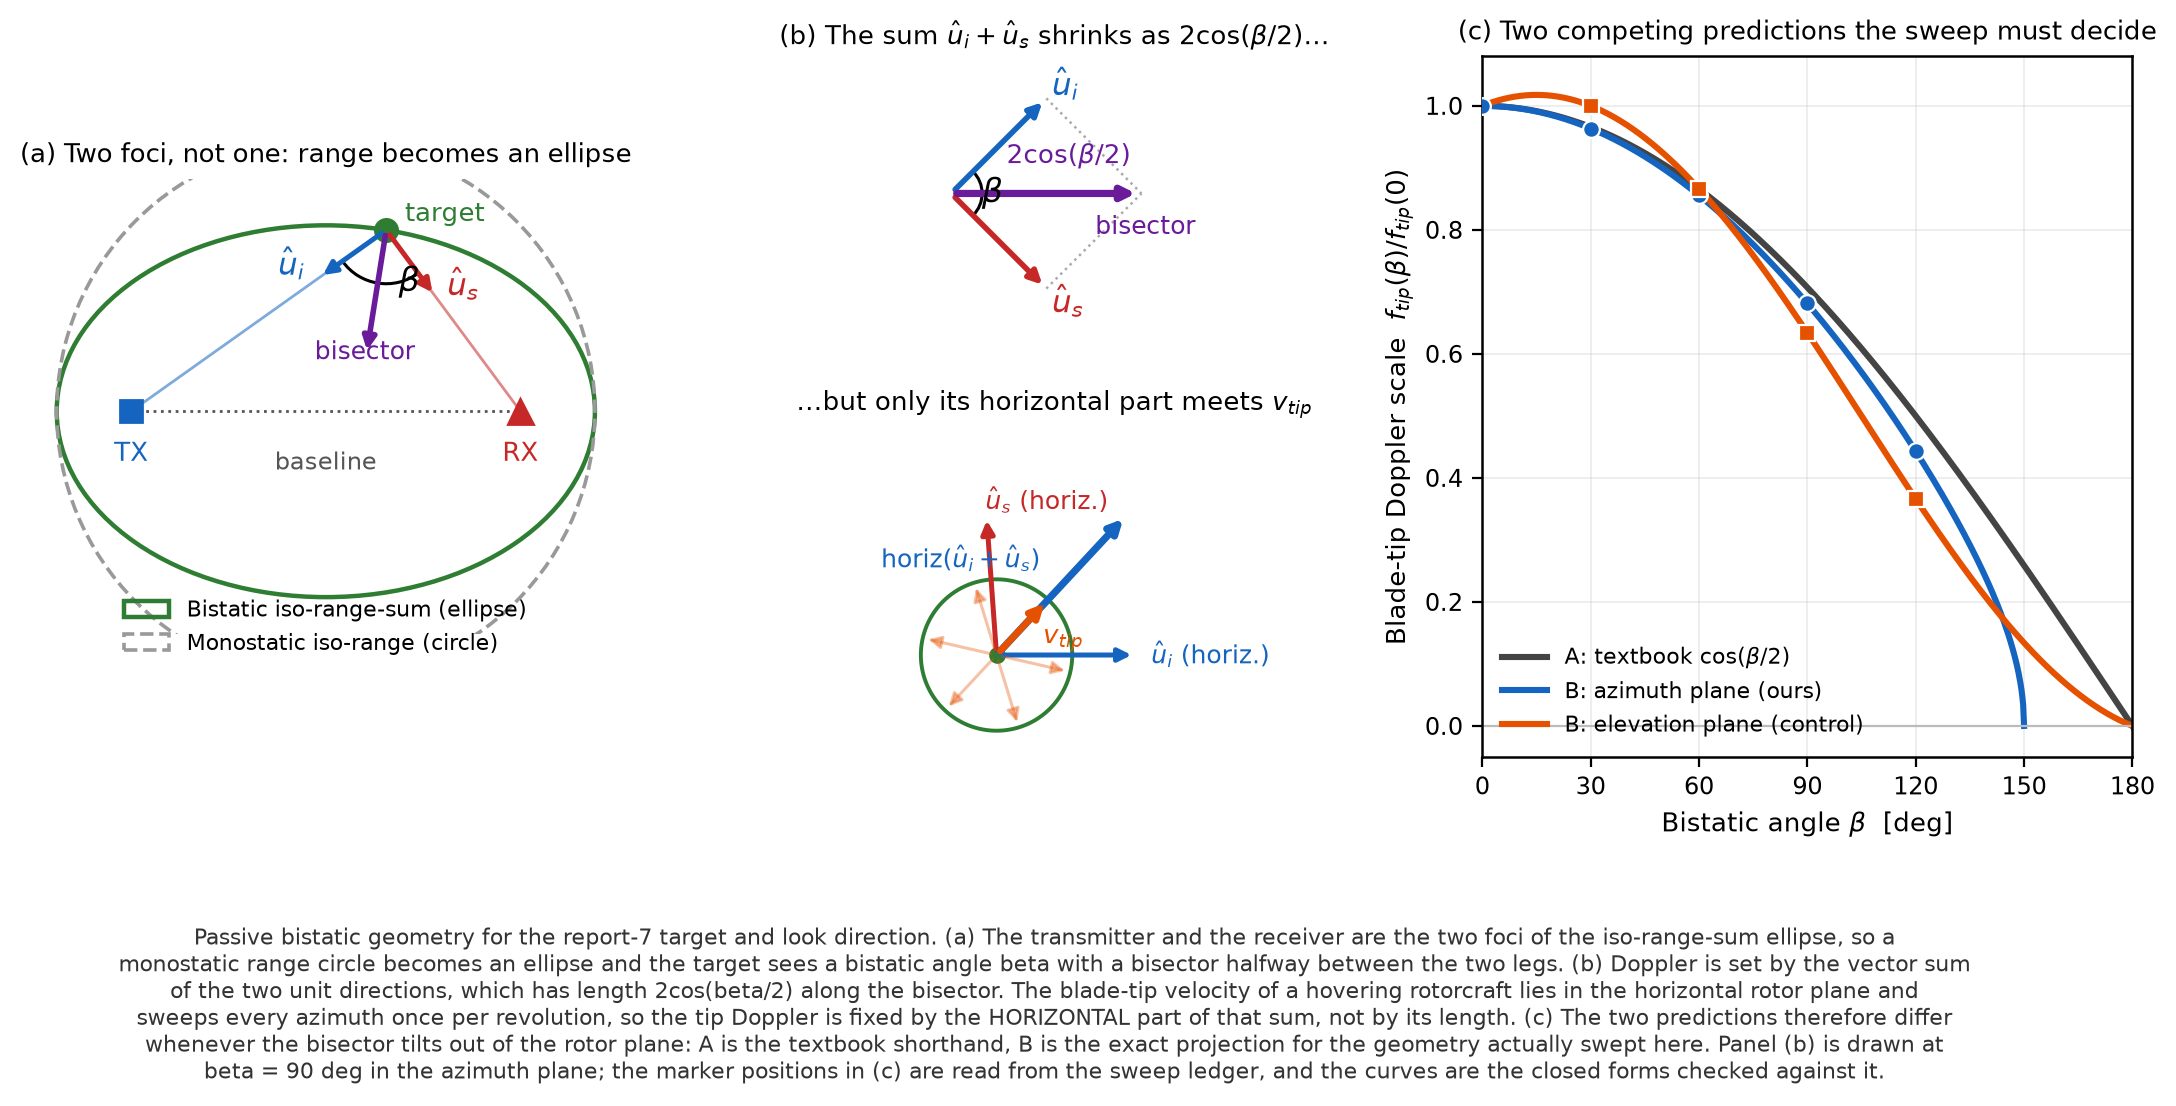

**(a) 초점이 둘이 된다.** 모노에서 «거리»는 원이었다. 바이스태틱에서 관측량은 송신국→표적→수신국 **거리의 합**이고, 그 등고선은 두 지상국을 초점으로 하는 **타원**이다. 표적이 두 다리 사이에 보는 각이 β 이고, 그 사이를 반으로 가르는 방향이 **이등분선**이다.

**(b) 도플러는 두 시선의 벡터 합이 정한다.**

$$f_d=\frac{1}{\lambda}\,\mathbf{v}\cdot(\hat u_i+\hat u_s)=\frac{2\cos(\beta/2)}{\lambda}\,\mathbf{v}\cdot\hat u_b$$

합벡터의 **길이**가 2cos(β/2) 라는 것이 «×cos(β/2)» 축약의 출처다. 그런데 그 축약이 맞으려면 **v·û_b 가 v·û_i 와 같아야** 한다 — 즉 이등분선이 속도가 놓인 평면 안에 있어야 한다. 호버링 로터의 날개끝 속도는 **수평**이고 한 회전에 모든 방위를 훑으므로, 우리가 실제로 재는 최대 도플러는

$$f_{tip}(\beta)=\frac{v_{tip}}{\lambda}\,\bigl|\mathrm{horiz}(\hat u_i+\hat u_s)\bigr|\qquad\Longrightarrow\qquad\frac{f_{tip}(\beta)}{f_{tip}(0)}=\frac{|\mathrm{horiz}(\hat u_i+\hat u_s)|}{2\cos el}$$

**(c) 그래서 예측이 둘이다.** 교과서 축약을 **A**, 위 정확식을 **B** 라 부른다. 방위면에서 둘은 β 120° 에서 11 % 갈리고, 앙각면에서는 **27 %** 갈린다. 대조군 평면을 둔 이유가 이것이다 — 두 예측이 멀어야 계산이 고를 수 있다.

⚠ A 가 틀린 식이라는 뜻이 아니다. A 는 «이등분선 방향의 속도 성분» 을 이미 알고 있을 때 쓰는 축약이고, 우리처럼 **표적 좌표계에 고정된 운동**(수평 회전)을 볼 때는 이등분선이 기울면서 생기는 cos δ 가 따로 붙는다. B 는 그 둘을 합쳐 쓴 것이다.


## 그림 2 — β 를 열었을 때 실제로 무엇이 나오나

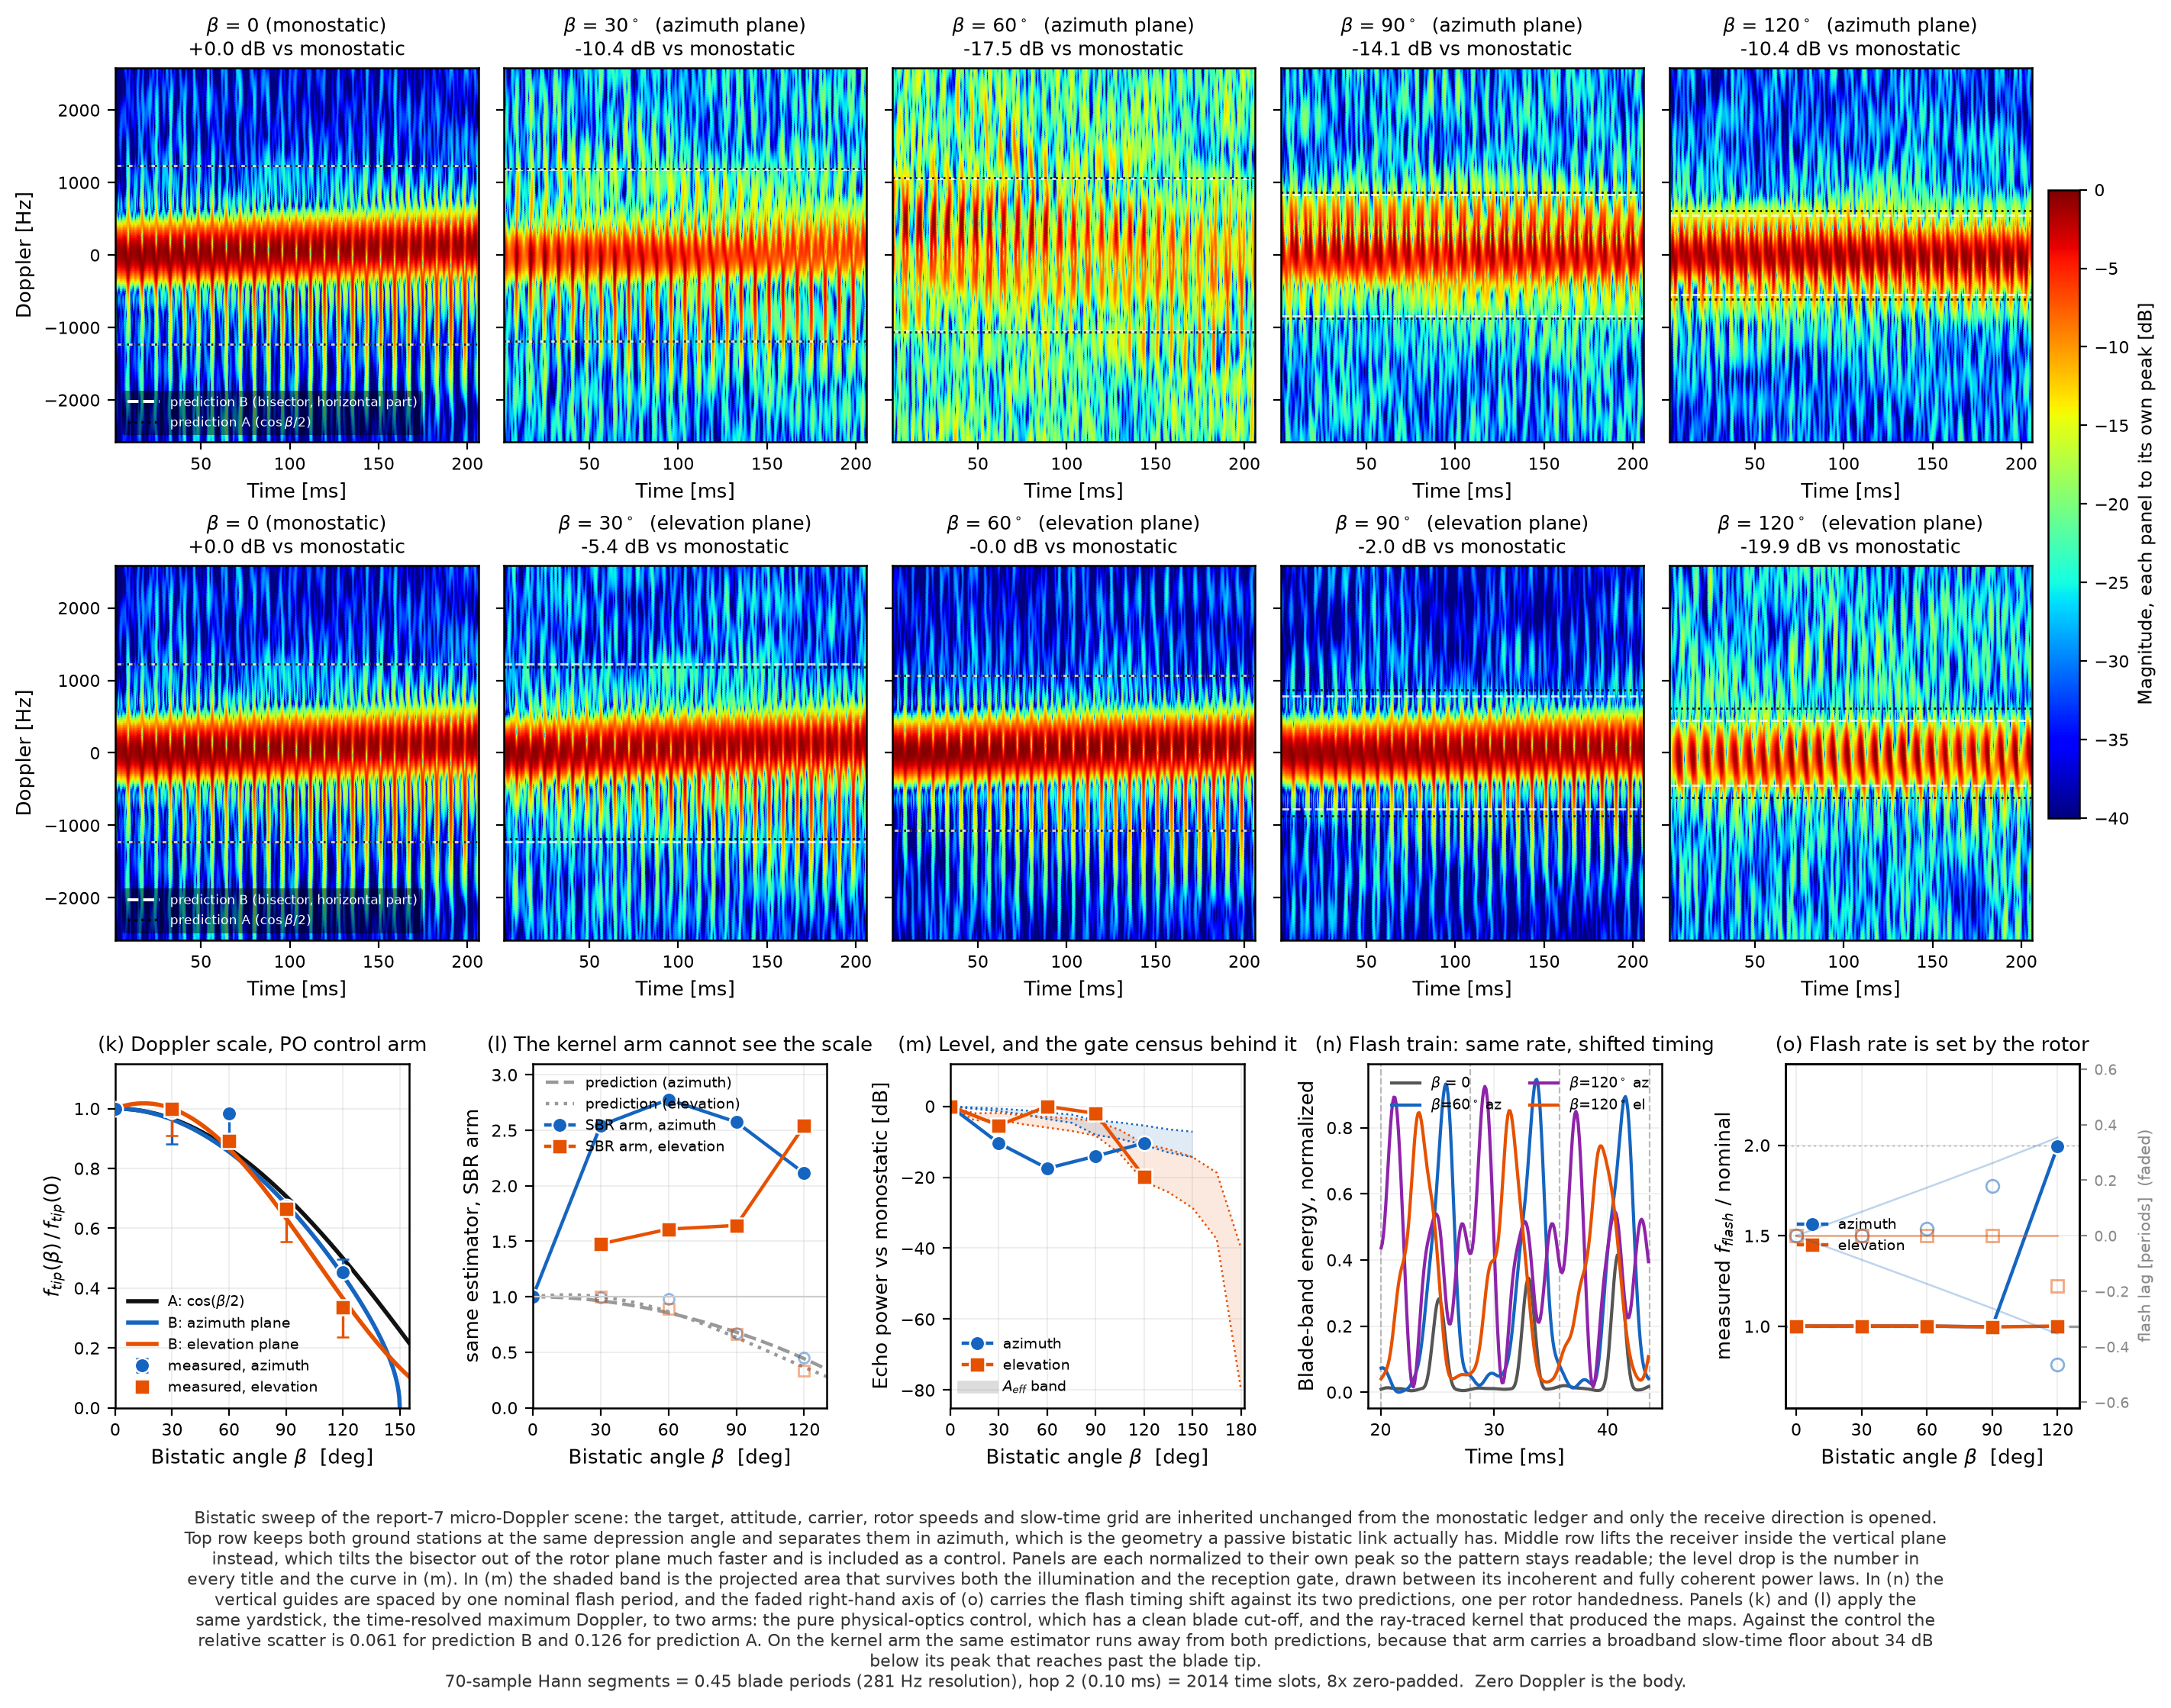

윗줄이 방위면(우리 기하), 가운뎃줄이 앙각면(대조군)이다. 두 줄 다 맨 왼쪽은 같은 β=0 칸 — 8 권 모노 편의 그 원장이다. 각 패널의 흰 파선이 **예측 B**, 검은 점선이 **예측 A** 다. 아랫줄 다섯 칸이 수치 판정이다.

⭐ 맵의 표시 규약은 `src/md_mapstyle.py` 가 강제한다 — 8 권 모노 편과 **같은 설정**이다(조각 0.45 블레이드 주기 · hop 2 · 8배 제로패딩 · jet · 0~−40 dB). 다섯 칸을 각자 최대로 정규화했으므로 **무늬**를 비교하는 그림이고, **레벨**은 제목의 숫자와 (m) 칸이 맡는다.

⚠ 맵만 보고 축척을 눈으로 재려 하면 안 된다. 이 표시 규약의 주파수 분해능은 281 Hz(조각 = 블레이드 0.45 주기)인데 방위면에서 두 예측의 간격은 최대 70 Hz 라 **원리적으로** 맵에서는 안 갈린다. 그래서 판정은 (k) 칸의 별도 추정기가 한다.


## 절 1. 도플러 축척 — 이등분선이 이긴다

**재는 법.** 날개끝 도플러는 한 회전 안에서 **잠깐만** 도달하는 시간 사건이다. 그래서 시간-주파수 평면에서 슬롯마다 «그 슬롯의 최고 |f|» 를 재고(능선 규약 STFT · 슬롯당 −20 dB · 99 분위) 그 값을 β=0 대비 비율로 쓴다. ⚠ 절대값에는 계통 편향이 있다 — β=0 에서 이 추정기가 내는 1159 Hz 는 운동학이 예측하는 1229 Hz 보다 5.6 % 낮다(창·임계값 탓). **비율**로만 쓰므로 그 편향은 상쇄된다.

**어느 팔에서 재나.** 판정은 **순수 PO 팔**에서 한다 — 그 팔은 날개끝에서 스펙트럼이 절벽처럼 잘린다(바닥 -127 dB). 광선 팔(SBR)은 바닥이 -62 dB 뿐이라 같은 잣대가 안 선다 — 절 2.

⭐ **바이스태틱 PO 를 어떻게 모노 코드로 재나** — 위상 항등식 하나로 된다.

$$e^{jk(\hat u_i+\hat u_s)\cdot p}=e^{j2k'\hat u_b\cdot p},\qquad k'=k\cos(\beta/2)$$

즉 **바이스태틱 위상 = 이등분선 시선의 모노 위상 @ 반송파 fc·cos(β/2)** 다. 그래서 `src/microdoppler.py` 를 한 줄도 안 고치고 그대로 불러 대조팔을 만든다(회귀 ③ 이 β=0 에서 8 권 모노 편의 PO 팔과 비트동일임을 확인한다).

| 라벨 | 평면 | β | 예측 A cos(β/2) | 예측 B 이등분선 | 실측 | 실측/A | 실측/B |
|---|---|---|---|---|---|---|---|
| `az0` | azimuth | 0° | 1.000 (1229 Hz) | 1.000 (1229 Hz) | **1.000** | 1.000 | 1.000 |
| `az30` | azimuth | 30° | 0.966 (1187 Hz) | 0.963 (1184 Hz) | **0.992** | 1.027 | 1.029 |
| `az60` | azimuth | 60° | 0.866 (1064 Hz) | 0.856 (1051 Hz) | **0.983** | 1.135 | 1.149 |
| `az90` | azimuth | 90° | 0.707 (869 Hz) | 0.681 (837 Hz) | **0.672** | 0.951 | 0.987 |
| `az120` | azimuth | 120° | 0.500 (614 Hz) | 0.443 (544 Hz) | **0.454** | 0.908 | 1.025 |
| `el30` | elevation | 30° | 0.966 (1187 Hz) | 1.000 (1229 Hz) | **1.000** | 1.035 | 1.000 |
| `el60` | elevation | 60° | 0.866 (1064 Hz) | 0.866 (1064 Hz) | **0.891** | 1.029 | 1.029 |
| `el90` | elevation | 90° | 0.707 (869 Hz) | 0.634 (779 Hz) | **0.664** | 0.939 | 1.047 |
| `el120` | elevation | 120° | 0.500 (614 Hz) | 0.366 (450 Hz) | **0.336** | 0.672 | 0.918 |

⭐ **판정: B (이등분선의 수평투영).** 상대 rms 오차가 **A 0.126 대 B 0.061** 다. 가장 날카로운 칸은 `el120` — 두 예측이 0.500 ↔ 0.366 로 가장 멀고, 실측 0.336 는 A 를 33 %, B 를 8 % 빗나간다.

⚠ **정직 표시 셋.**
① 방위면만 보면 두 예측의 간격이 11 % 이하라 **이 원장의 추정기 산포**(임계값을 ±5 dB 흔들면 0.083)와 겹친다 — 방위면 단독으로는 A 와 B 를 못 가른다. 앙각면 대조군이 있어야 갈린다.
② 이 판정은 **위상 항등식과 같은 대수를 공유**한다. 그러니 «독립적인 물리 검증» 이 아니라, 그 대수가 **실제 블레이드 형상·네 로터의 회전수 산포·유한 스팬**을 태웠을 때도 예측한 자리에 에너지가 놓이는지를 재는 **일관성 검사**다. 그 구분을 흐리지 않는다.
③ 잔차가 0 이 아니다 — 최대 0.128(라벨 `az60`). 빗살 간격(f_flash)이 유한하고 스펙트럼 포락 모양이 β 마다 조금씩 달라지는 것이 남은 산포다. 이것은 **미해결로 둔다**.


## 절 2. 광선 팔로는 이 축척을 못 잰다 — 그리고 그것은 바이스태틱 탓이 아니다

그림 2 의 (l) 칸이 말하는 것. 같은 잣대를 **광선 팔(SBR)** 에 대면 실측 비율이 **1.00 ~ 2.78** 로 나온다 — β>0 인 8 칸이 하나도 빠짐없이 1.48 배 위로 뛴다. 즉 «바이스태틱이 되면 최대 도플러가 커진다» 는, 물리적으로 말이 안 되는 답이다.

원인은 그 팔의 슬로타임 신호가 **광대역 바닥**을 깔고 있기 때문이다. 커널이 자세마다 광선 격자를 다시 정의하므로 위상 원점이 흔들리고 히트 집합이 갈리며, 그 흔들림이 슬로타임에서 백색에 가까워 도플러축 전체에 평평하게 퍼진다. β 가 커지면 코히어런트 합은 줄어드는데 그 바닥은 안 줄어서, 상대적으로 더 두드러진다.

⭐ **이것은 바이스태틱의 성질이 아니다.** 8 권 모노 편의 모노 원장에 있는 세 팔을 **같은 추정기**로 재면 바로 보인다.

| 모노 원장의 팔 | **전체 전력** 중 f_tip 밖 몫 | 날개끝 밖 바닥 (봉우리 대비) |
|---|---|---|
| Ours, nothing blocked (control) | 0.00007 % | -127.2 dB |
| Sionna PathSolver | 5.06 % | -47.6 dB |
| Ours (SBR+PO, 기본) | 0.18 % | -62.2 dB |

⚠ **이 표의 두 줄은 격자가 다르다.** 모노 원장의 SBR 열은 **얼린 광선 격자**로 다시 났고(그 전후 비교는 [리포트 8-2 «광선 격자를 어디에 매나»](08_2_engines.ipynb)), **이 편의 β 스윕은 아직 옛 판**이다. 두 표의 절대값을 이어 붙여 읽지 마라. ⭐ 얼린 뒤에도 SBR 의 대역밖 절대 전력은 순수 PO 보다 34.6 dB 위다 — 아래 논지는 그대로 선다.

공칭 날개끝은 1229 Hz 다. 순수 PO 는 거기서 잘리고, **광선을 쓰는 두 팔은 둘 다** 그 너머로 새어 나간다. 8 권 모노 편이 «다음에 할 것» 으로 적어 둔 «SBR 의 날개끝 밖 능선을 규명한다» 가 바로 이것이고, 이 편은 그것이 **무엇을 못 하게 만드는지**를 계량한다 — 광선 팔의 슬로타임 스펙트럼에서는 날개끝 축척을 읽을 수 없다.

**이 칸의 정의.** 평활 없는 Hann 주기도의 **절대** 대역 전력이다 — P_out = Σ|X(f)|², |f| > f_tip. 세 팔은 단위가 같지 않으므로(Sionna 는 채널계수다) 그 절대량을 **전체 전력**으로 나눠 나란히 놓는다. 열 제목에 분모를 박아 둔 것이 그 뜻이고, 대역 경계가 분모에 안 들어간다.

⚠ **옛 «블레이드 전력 중» 비율(SBR 0.70 % · Sionna 13.78 % · PO 0.02 %)는 인용하지 않는다.** 그 분모는 포락 평활 커널(507 Hz)이 대역 시작(184 Hz)보다 넓어 동체 DC 봉우리를 대역 안으로 끌어온다. 분모 중 그 번짐의 몫이 SBR 97 % · Sionna 68 % · PO 99 % 라, 그 비율이 실제로 재는 것은 «동체 DC 대비» 다.

⭐ **순위는 분모가 정한다 — 그래서 분모를 밝히지 않고는 대소를 쓰지 않는다.** 헤드라인(전체 전력 대비)으로는 SBR 0.18 % 가 Sionna 5.06 % 보다 14.5 dB 아래다. 같은 두 팔을 **대역비**(f_tip 밖 / 블레이드 대역)로 재면 Sionna 77.1 % 대 SBR 26.2 % 로 **순서는 같다**(4.7 dB 차). 이 편은 그 대역비를 헤드라인으로 안 쓴다. 이유가 둘이다 — 분모 P_in 자체가 SBR 에서 독립 엔진(순수 PO) 대비 19.1 dB 부풀어 있어 그 자리도 격자 잡음이고, 두 대역의 폭이 8.3 배 다르다.

⚠ **순수 PO 의 절대값은 «0 에 가깝다» 의 기준선으로만 쓴다.** f_tip 을 5 % 올려 자르면 광선 두 팔은 0.6~0.0 dB 움직이는데(넓은 바닥) 순수 PO 는 5.1 dB 움직인다(절벽). PO 칸이 재는 것은 바닥 높이가 아니라 절벽을 어디서 잘랐는가다.

⭐ **이 바닥의 원인은 광선 격자의 이산화가 아니라 자세마다 격자를 다시 정의하는 것이다.** 격자를 얼리면 λ/12 에서 대역밖 절대 전력이 13.1 dB 내려가고, 얼린 팔만 예측대로 d² 로 수렴한다(기울기 -2.19 · R² 0.998, 생산 팔은 -0.56). 그 기전과 대가는 [리포트 5 «우리 커널 — 무엇이고, 무엇이 아닌가»](05_kernel.ipynb) 가 잰다. 이 편의 스윕은 아직 얼린 격자를 안 쓴다.

⚠ 그렇다고 광선 팔의 맵이 틀렸다는 말이 아니다. 레벨(절 3)·플래시(절 4)·가림은 광선 팔이 맡는 것이고 이 편의 그 결과들은 전부 광선 팔에서 나온다. 못 하는 것은 **날개끝 가장자리의 정밀 측정** 하나다.


## 절 3. 레벨 — 게이트 두 개가 겹치는 만큼만 돌아온다

β 가 커지면 조명게이트(n̂·û_i > 0)와 수신게이트(n̂·û_s > 0)가 겹치는 면이 줄어든다. 얼마나 줄어드는지는 커널의 **바로 그 광선 격자**를 다시 쏘아 세었다(자세 24 개 평균 — 슬로타임 4,096 프레임에서 고르게 뽑았다. 장 계산 없이 넓이만 센다).

| β | 방위면 A_eff | 모노 대비 | 앙각면 A_eff | 모노 대비 |
|---|---|---|---|---|
| 0° | 288 cm² | 100.0 % | 288 cm² | 100.0 % |
| 30° | 245 cm² | 85.0 % | 186 cm² | 64.6 % |
| 60° | 190 cm² | 66.1 % | 144 cm² | 50.1 % |
| 90° | 114 cm² | 39.5 % | 111 cm² | 38.5 % |
| 120° | 82 cm² | 28.5 % | 25 cm² | 8.7 % |
| 150° | 55 cm² | 19.2 % | 11 cm² | 3.7 % |

**측정 에코는 그 면적만큼 곧이곧대로 줄지 않는다.**

| 라벨 | β | 에코 레벨 (모노 대비) | 진폭 p-p |
|---|---|---|---|
| `az30` | 30° azimuth | -10.4 dB | 37.5 dB |
| `az60` | 60° azimuth | -17.5 dB | 48.1 dB |
| `az90` | 90° azimuth | -14.1 dB | 35.3 dB |
| `az120` | 120° azimuth | -10.4 dB | 41.3 dB |
| `el30` | 30° elevation | -5.4 dB | 11.5 dB |
| `el60` | 60° elevation | -0.0 dB | 4.3 dB |
| `el90` | 90° elevation | -2.0 dB | 5.9 dB |
| `el120` | 120° elevation | -19.9 dB | 39.4 dB |

⭐ 읽는 법 — 그림 2 의 (m) 칸에서 음영 띠가 **A_eff 가 허용하는 범위**다(아래 선은 완전 비코히어런트 10·log₁₀, 위 선은 완전 코히어런트 20·log₁₀). 측정 레벨이 그 띠 근처에서 **오르내린다** — 단조 감소가 아니다. 방위면에서 가장 약한 칸은 **가장 큰 β 가 아니라** β 60° (-17.5 dB)이고, 거기서 β 120° 로 더 벌리면 오히려 +7.1 dB **돌아온다**. 앙각면 β 60° 는 모노와 거의 같다(-0.0 dB).

이유는 **코히어런트 간섭**이다. 면적이 줄어도 남은 면들의 위상이 어떻게 맞물리느냐가 합을 정한다 — 면적은 상한을 정할 뿐이다. 그래서 «β 가 크면 얼마나 손해인가» 는 한 숫자로 못 쓰고 **기하마다 다시 재야 한다**. 그것이 이 표의 쓰임새다.

⚠ A_eff 는 **투영 면적**이지 σ 가 아니다. 재질 Γ·위상은 안 들어간다 — 그래서 «게이트가 얼마나 좁아지나» 의 진단이지 레벨의 예측이 아니다.


## 절 4. 플래시 — 주기는 로터가, 시각은 방위가 정한다

⭐ 이 편에서 가장 또렷하게 갈린 것. **도플러와 플래시는 같이 움직이지 않는다.**

**플래시 주기는 β 에 안 변한다.**

8/9 칸에서 측정 플래시율이 공칭 126.67 Hz 다. 남은 한 칸(`az120`)은 포락 스펙트럼의 최대선이 **2차 고조파**로 넘어간 것이고, 정수배로 보면 **모든 칸이 공칭 격자의 ±0.8 Hz 안**이다. 플래시율은 «로터가 몇 번 도는가» 이지 «어디서 보는가» 가 아니다.

**플래시 시각은 이등분선의 방위가 정한다.**

| 라벨 | β | 이등분선 방위 | 도플러 축척 | 플래시열 상관 (β=0 대비) | 플래시 밀림 |
|---|---|---|---|---|---|
| `az30` | 30° azimuth | 15.5° | 0.992 | **0.964** | +0.000 주기 |
| `az60` | 60° azimuth | 31.2° | 0.983 | **0.494** | +0.026 주기 |
| `az90` | 90° azimuth | 47.1° | 0.672 | **0.509** | +0.180 주기 |
| `az120` | 120° azimuth | 63.7° | 0.454 | **0.657** | -0.463 주기 |
| `el30` | 30° elevation | 0.0° | 1.000 | **0.989** | +0.000 주기 |
| `el60` | 60° elevation | 0.0° | 0.891 | **0.986** | +0.000 주기 |
| `el90` | 90° elevation | 0.0° | 0.664 | **0.979** | +0.000 주기 |
| `el120` | 120° elevation | 0.0° | 0.336 | **0.746** | -0.180 주기 |

⭐ 표를 가로로 읽지 말고 **두 세로줄을 비교**하라.
· `el60` — 도플러는 0.891 로 이미 11 % 줄었는데 플래시열은 상관 **0.986** 로 제자리다.
· `az60` — 도플러는 거의 그대로(0.983)인데 플래시열 상관은 **0.494** 로 무너진다.
두 칸의 β 는 같다. 다른 것은 이등분선의 **방위가 돌았는가** 뿐이다.

**왜 그런가.** 도플러는 **운동**에서 온다 — 속도를 이등분선에 투영한 것이다. 플래시는 **기하**에서 온다 — 블레이드가 이등분선에 정렬하는 순간에 터지므로, 이등분선의 방위가 Δ 만큼 돌면 플래시 시각이 Δ/(360°·f_rev) 만큼 밀린다. 이등분선의 **부각**만 바꾸는 앙각면에서는 그 정렬 시각이 안 바뀐다.

⚠ 밀림의 **부호**까지는 못 맞춘다. 이 기체는 로터가 짝을 지어 반대로 돌기 때문에(회전 방향 [1, -1, 1, -1]), 이등분선이 Δ 돌면 CCW 로터의 플래시는 뒤로 밀리고 CW 로터는 앞으로 당겨진다 — 예측이 하나가 아니라 **±둘**이고, 네 로터를 합친 포락은 둘 사이 어딘가에 놓인다. 그림 2 (o) 칸의 흐린 축이 그 두 예측선과 실측을 겹쳐 놓은 것이다. 우리가 여기서 주장하는 것은 **상관이 무너지는가 아닌가**까지이고, 밀림의 부호·크기를 로터별로 가르는 것은 **안 한 일**이다.

⚠ `el120` 은 예외다 — 이등분선 방위가 안 돌았는데도 상관이 0.746 로 떨어진다. 그 칸은 레벨이 -19.9 dB 로 이 스윕에서 가장 많이 무너진 칸이고(로터를 위에서 내려다보는 기하다), 무늬 자체가 달라졌다. 미해결로 둔다.


## 절 5. 정직 — 이 편이 딛고 선 근사와, 안 한 일

**커널의 적용범위 한계** (`rcs_sbr.sbr_field_bistatic` 이 물려받은 것 그대로)

- lit-PO 전방산란 무효: β→180° 에서 조명·수신 게이트가 상호배타 → E≡0. 그림자복사(Babinet 전방로브 4πA²/λ²)를 못 낸다. β=120° 가 그 벼랑에서 얼마나 떨어졌는지는 census 표가 잰다.
- 상반성 부분성립: û_i 단일 조명격자를 재사용하므로 E(û_i,û_s) ↔ E(û_s,û_i) 가 비볼록 표적에서 어긋난다(격자세분으로 안 줄어듦).
- 투과 출사경로는 입사 τ=1−|Γ|² 로 근사한 1차 투과 — 바이스태틱 비대칭을 더 키운다.
- obliquity 는 표준 PO 의 (n̂·û_i) 그대로 — 대칭 √((n̂·û_i)(n̂·û_s)) 는 폐기된 시도다.
- ⚠ 기하만 본다. 기준채널/감시채널 2채널 처리(ECA·CAF, src/passive_process.py)는 이 편에서 쓰지 않는다 — 다음 단계다.
- 도플러 **부호**는 검증하지 않았다 — 로터 스펙트럼이 거의 대칭이라 이 원장으로는 부호 규약을 가를 수 없다.

**⚠ 전방산란 무효가 얼마나 가까운가 — 숫자로.**

lit-PO 는 β→180° 에서 조명게이트와 수신게이트가 **상호배타**가 되어 E ≡ 0 이 된다. 그림자복사(Babinet 전방로브 4πA²/λ²)를 원리적으로 못 낸다. 게이트 센서스가 그 벼랑을 직접 보여준다.

| β | 방위면 A_eff (모노 대비) | 앙각면 A_eff (모노 대비) |
|---|---|---|
| 90° | 39.5 % | 38.5 % |
| 120° | 28.5 % | 8.7 % |
| 150° | 19.2 % | 3.7 % |
| 165° | — (등부각 원뿔 밖) | 1.3 % |
| 180° | — (등부각 원뿔 밖) | 0.0 % |

⭐ **β = 120° 는 아직 벼랑이 아니다** — 방위면에서 모노의 28 % 가 남아 있고, 에코도 -10.4 dB 로 살아 있다. 벼랑은 그 너머다: 앙각면 165° 에서 1.3 %, 180° 에서 **정확히 0** 이 된다(게이트가 완전히 배타적이 되는 지점). 그러니 이 편의 β 범위 안에서는 lit-PO 의 그 한계가 **결과를 지배하지 않는다** — 다만 β ≳ 150° 를 물으려면 이 커널로는 안 되고 그림자복사를 따로 넣어야 한다.

**⚠ 이 편이 안 한 일 — 경계선**

우리가 연 것은 **기하** 하나다: «표적이 그 기하에서 무엇을 되돌려주는가». 패시브 수신기가 실제로 하는 일은 그 다음이다 —

| 안 한 것 | 어디 있나 | 왜 이 편에서 안 하나 |
|---|---|---|
| 기준채널/감시채널 2채널 처리 | `src/passive_process.py` (ECA·CAF·거리-도플러) | 이 편의 관측량은 표적 에코 하나다. 2채널을 넣으면 직접파 누설 제거 성능이 결과에 섞여 «기하가 무엇을 했는가» 가 안 보인다 |
| 직접파(기선 신호)·정적 클러터 | 같은 파일 (ECA 가 담당) | 위와 같음 |
| 거리합 타원 위의 실제 배치(기선 길이·거리) | — | β 만 여는 것이 이 편의 설계다. 레벨의 절대값은 배치가 정하고, 여기 레벨은 전부 **모노 대비 상대값**이다 |
| 도플러 **부호** 규약 | — | 로터 스펙트럼이 거의 대칭이라 이 원장으로는 못 가른다 |

**다음 단계** — 이 편의 슬로타임 열 E(t; β) 를 `passive_process.make_cpi` 의 표적 채널로 넣고 ECA 를 태우면, «β 가 크면 표적이 약해지는데 직접파 제거는 그대로인가» 를 물을 수 있다. 그 2채널 축은 [리포트 11-2 «기준채널이 현실이면 얼마를 잃는가»](11_2_two_channel.ipynb) 가 기준채널 잡음·다중경로 단일축으로 이미 열었다 — 남은 것은 **그 두 축을 잇는 것**, 즉 이 편의 β 를 그 사슬의 표적 채널로 넣는 일이다.


## ⭐ 모노 ↔ 바이스태틱 대조표

8 권 모노 편의 어느 수치가 어떻게 달라지나. β 는 방위면 기준이다.

| 무엇 | 8 권 모노 편 | 이 편 β 30° | β 60° | β 90° | β 120° | 무엇이 그렇게 만드나 |
|---|---|---|---|---|---|---|
| 날개끝 도플러 f_tip | **1229 Hz** | 1184 Hz | 1051 Hz | 837 Hz | 544 Hz | 이등분선의 수평 성분 |
| 도플러 축척 (실측) | 1.000 | 0.992 | 0.983 | 0.672 | 0.454 | 위와 같음 |
| 플래시율 f_flash | **126.7 Hz** | 126.9 Hz | 126.9 Hz | 126.3 Hz | 126.3 Hz | **안 변한다** — 로터 회전수가 정한다 |
| 플래시열 상관 (β=0 대비) | 1.000 | 0.964 | 0.494 | 0.509 | 0.657 | 이등분선 **방위**가 돌면 정렬 시각이 밀린다 |
| 에코 레벨 | 0.0 dB (기준) | -10.4 dB | -17.5 dB | -14.1 dB | -10.4 dB | 게이트 겹침 + 코히어런트 간섭 |
| 게이트 유효면적 A_eff | **288 cm²** | 85 % | 66 % | 39 % | 28 % | 두 게이트의 겹침 |
| 거리 관측량 | 표적까지 거리 (원) | ← 송·수신 **거리의 합** (타원) → | | | | 초점이 둘 |
| 슬로타임 격자 | 4,096 @ 19700 Hz | ← **같음** → | | | | 설계상 고정 |
| 표시 규약 | flash_spec 0.45 주기 | ← **같음** → | | | | `md_mapstyle` 가 강제 |

⭐ **한 줄로**: 바이스태틱이 되면 **도플러축이 눌리고 에코가 약해지지만, 플래시 격자는 그대로 남는다**. 분류기가 기댈 특징 중 «회전수» 계열은 기하에 강건하고, «날개끝 주파수» 계열은 기하를 알아야 쓸 수 있다는 뜻이다.


## 부록 — 그림별 데이터 이력

| 그림 | 원장 | 생성 | Γ(θ) | 로터 산포 |
|---|---|---|---|---|
| 1 (기하) | 수치 없음 — β·φ·이등분선만 `outputs/report07b_bistatic_md.json` 에서 읽는다 | 2026-08-10T10:31 | — | — |
| 2 (결과) | `outputs/report07b_bistatic_md.{json,npz}` | 2026-08-10T10:31 | ✅ 후 (커널 기본값) | ±0.22 %(PX4 **SITL**(시뮬) 로그 중간값 — 8 권 모노 편 상속) |
| 2 의 회귀·바닥 비교 | + `outputs/report07_three_engines.npz` | 2026-08-10 19:18 | ✅ 후 | 같음 |

이 편의 원장은 **8 권 모노 편의 원장에서 파생**된다 — `_meta` 를 읽어 세팅을 맞추고, β=0 열을 그 원장과 대조한다(절 0 회귀 표). 8 권 모노 편의 원장이 다시 계산되면 이 편도 다시 돌려야 한다.


## 부록 — 그림을 만든 설정 전부

그림 안에는 무늬를 읽는 데 필요한 표시 설정만 한 줄로 적는다. 계산 설정 전부는 여기 있다.

**계산**

| 항목 | 값 | 근거 |
|---|---|---|
| 기체 | DJI Matrice 4E | 1차 실측 표적 |
| 반송파 | 3.5 GHz | 5G n78 |
| 조명 시선 û_i | 방위 0° · 앙각 -15° | 8 권 모노 편 상속 |
| 로터별 회전수 | 3808, 3792, 3795, 3805 rpm (산포 ±0.22 %) | 8 권 모노 편 상속 (PX4 **SITL**(시뮬) 로그 중간값 — 실기 텔레메트리가 아니다) |
| 로터 회전 방향 | [1, -1, 1, -1] · 블레이드 2장 | 기체 CAD |
| PRF | 19700 Hz | 8 권 모노 편 상속 (16×f_tip) |
| 표본 수 | 4,096 = 208 ms = 26.3 블레이드 주기 | 8 권 모노 편 상속 |
| 수신 방향 수 | 9 (방위면 5 + 앙각면 4) | 조명은 û_i 로 **한 번만** 쏘고 수신방향마다 위상합 + 그림자광선 1발만 반복한다 |
| 광선 간격 | λ/12 | `rcs_sbr.DEFAULT_DIV` (spacing 미지정) |
| jitter | **없음** (단일 격자) | 위상을 쓰는 하류라 격자 평균이 의미를 바꾼다 |
| 재질 Γ | 각도의존 Γ(θ), 국소 입사각 cosθ = n̂·û_i | 모노 경로와 같은 규약 |
| 계산 시간 | 891 s = 218 ms/자세 (수신방향 9개 동시) | GPU 2 · irsgpu1 |
| 동체선 제외 폭 | |f| < 184 Hz | 0.15 × 모노 f_tip |

**표시 — `src/md_mapstyle.py` 가 강제한다 (8 권 모노 편과 같음)**

| 항목 | 값 |
|---|---|
| 조각 길이 | 블레이드 0.45 주기 (`auto_periods` 가 고른 값) |
| 겹침(hop) · 제로패딩 | 2 표본 · 8배 |
| 창 · 음영 · 색역 | Hann · gouraud · jet 0~−40 dB |
| 정규화 | 패널마다 자기 최대 |
| 주파수 표시 범위 | ±2.1 × 모노 f_tip 으로 **잘라서** 넘긴다 (표시 범위 조정) |

**추정기**

| 무엇 | 어떻게 |
|---|---|
| 도플러 축척 (주) | 순수 PO 대조팔에 **시간분해 최대 도플러**(ridge_spec STFT · 슬롯당 −20 dB · 99 분위) |
| 플래시율 | 날개끝 띠의 시간축 에너지 b(t) 의 지배 선주파수 |
| 플래시 밀림 | b(t) 와 β=0 의 b₀(t) 의 정규화 상호상관 최대 자리 (±½주기 안) |
| 게이트 센서스 | 커널의 광선 격자를 다시 쏘아 두 게이트 ∩ 출사가시성에 남는 히트 수 × d² |
| 대역밖 전력 (절 2) | 평활 없는 Hann 주기도(4배 제로패딩)의 절대 대역 전력 P_out = Σ|X(f)|², |f| > f_tip. 정규화는 **전체 전력** ⟨outputs/outofband_power.json : new_definition.headline⟩ |
| 날개끝 밖 바닥 (절 2) | 같은 주기도에서 f_tip 밖 구간의 평균을 봉우리 대비로 ⟨outputs/outofband_power.json : three_engines[0].new_floor_rel_db_raw_mean⟩ |


## 부록 — 코드 발췌

**바이스태틱 기하** (`benchmark/report07b_bistatic_md.py`) — 방위면에서 β 를 정확히 맞춘다

```python
def us_azimuth(az, el, beta):
    """등부각 원뿔: 두 지상국이 같은 부각, 방위만 φ 벌어진다."""
    if beta == 0.0:
        return look(az, el), 0.0          # ⭐부동소수 잔차 없이 û_s ≡ û_i
    ce, se = np.cos(np.radians(el)), np.sin(np.radians(el))
    c = (np.cos(np.radians(beta)) - se * se) / (ce * ce)   # cosβ = cos²el·cosφ + sin²el
    phi = float(np.degrees(np.arccos(c)))
    return look(az + phi, el), phi
```

**슬로타임 복소열** — 조명은 한 번, 수신방향은 여러 개

```python
E = np.zeros((NT, len(dirs)), complex)
for i in range(NT):
    E[i] = sbr_field_bistatic(fp.pose(ph[i]), GM, FC, u_i, U_s)   # U_s = (N,3)
```

**순수 PO 대조팔** — 위상 항등식으로 모노 코드를 그대로 쓴다

```python
ub = bisector(u_i, us)                                  # 이등분선
azb = degrees(arctan2(ub[1], ub[0])); elb = degrees(arcsin(ub[2]))
fcb = FC * cos(radians(beta) / 2)                       # ⭐k' = k·cos(β/2)
_, Epo[:, j], _ = microdoppler_series(spec, fc=fcb, az=azb, el=elb, prf=PRF,
                                      n_t=NT, rpm_per_rotor=rpms, spacing=SPACING_PO)
```

**게이트 센서스** — 물리를 재구현하지 않고 커널 자신의 씬·가시성을 불러 쓴다

```python
scene, shapes, gammas, matk = rsb._scene_for(mesh, GM, cache_key, fc)
...
lit = lit_i & ((Nn @ us) > 1e-6)                        # + 수신 게이트
lit[sel] = rsb._exit_visible(scene, P[sel], Nn[sel], us) # + 출사 가시성
A_eff = lit.sum() * d * d                               # [m²]
```


## 부록 — 재현

```bash
cd sionna2
# ① 스윕 계산 (GPU 2, 약 15 분) → outputs/report07b_bistatic_md.{npz,json}
SIONNA2_GPU=2 PYTHONPATH=src:benchmark ~/.venvs/py312/bin/python \
    benchmark/report07b_bistatic_md.py

# 측정·판정만 다시 (장은 그대로) — 추정기를 손볼 때
SIONNA2_GPU=2 PYTHONPATH=src:benchmark ~/.venvs/py312/bin/python \
    benchmark/report07b_bistatic_md.py --analyze-only

# ② 그림 둘
PYTHONPATH=src ~/.venvs/py312/bin/python benchmark/build_bistatic_geom_fig.py
PYTHONPATH=src ~/.venvs/py312/bin/python benchmark/build_bistatic_md_fig.py

# ③ 이 노트북
PYTHONPATH=src ~/.venvs/py312/bin/python src/make_report07b_bistatic.py
```

**딸린 파일**

| 무엇 | 어디 |
|---|---|
| 커널 | `src/rcs_sbr.py::sbr_field_bistatic` (이 편은 **안 고친다**) |
| 커널 계약 검사 | `benchmark/verify_bistatic_field.py` → `outputs/verify_bistatic_field.json` |
| 스윕 | `benchmark/report07b_bistatic_md.py` |
| 그림 | `benchmark/build_bistatic_geom_fig.py` · `benchmark/build_bistatic_md_fig.py` |
| 원장 | `outputs/report07b_bistatic_md.{json,npz}` · `outputs/figures/report07b_g{1,2}.{png,pdf}` |
| 상속한 모노 원장 | `outputs/report07_three_engines.{json,npz}` |

**남긴 문제**

| 무엇 | 왜 미해결인가 |
|---|---|
| 이 편의 스윕에 얼린 격자를 배선한다 | 원인은 «자세마다 격자를 다시 정의하는 것» 으로 규명됐고 커널에 `grid_ref` 가 배선돼 있다. 이 편의 바이스태틱 스윕은 그것을 안 넘긴다 |
| 도플러 축척의 남은 잔차 (최대 0.128) | 빗살 간격이 유한하고 포락 모양이 β 마다 조금 달라진다 |
| 플래시 밀림의 부호 | 로터가 짝을 지어 반대로 돌아 예측이 ±둘이다. 로터별 분해가 필요 |
| `el120` 의 플래시열 상관 저하 (0.746) | 이등분선 방위가 안 돌았는데도 무늬가 달라졌다. 레벨이 가장 많이 무너진 칸이다 |
| 2채널(ECA·CAF) 처리 | 이 편의 설계상 제외 — 그 축은 [리포트 11-2](11_2_two_channel.ipynb) 가 기준채널 잡음·다중경로로 연다. 이 편의 β 를 그 사슬에 넣는 것이 남았다 |
